In [1]:
# Import required geospatial, visualization, and data-processing libraries
# used for tornado track analysis, OSM data extraction, and mapping

import zipfile
import xml.etree.ElementTree as ET
import geopandas as gpd
from shapely.geometry import LineString
import pandas as pd
import osmnx as ox


kmz_file = "1210 Kentucky EF-4 Tornado.kmz"

# Extract tornado track coordinates from the KMZ damage survey file
# and convert them into a GeoDataFrame representing the tornado centerline

with zipfile.ZipFile(kmz_file) as z:
    kml_data = z.read("doc.kml")

root = ET.fromstring(kml_data)

coords = []

for elem in root.iter():
    if "coordinates" in elem.tag:
        coords.append(elem.text.strip())

# Convert coordinates to LineString
track_points = []

for c in coords:
    points = c.split()   # split into individual coordinate triplets
    
    for p in points:
        lon, lat, *_ = p.split(",")   # ignore altitude if present
        track_points.append((float(lon), float(lat)))

track_line = LineString(track_points)

# Create GeoDataFrame 
tracks = gpd.GeoDataFrame(
    {"name": ["Western KY EF4 Tornado"]},
    geometry=[track_line],
    crs="EPSG:4326"
)

tracks.head()

,name,geometry
0,Western KY EF4 Tornado,"LINESTRING (-88.02457 37.02632, -86.56382 37.5..."


In [2]:
# Create an estimated tornado damage swath by buffering the tornado
# centerline using the maximum reported tornado width

tracks_aea = tracks.to_crs("EPSG:5070")

width_m = 1600 # Roughly measured width of the tornado in meters

# Generate a proper spatial footprint of the tornado

swaths = tracks_aea.copy()
swaths["geometry"] = tracks_aea.buffer(width_m/2) # This helps represent the realistic damage swath compared to the actual width

swaths.head()

,name,geometry
0,Western KY EF4 Tornado,"POLYGON ((609592.067 1516702.524, 609549.678 1..."


In [3]:
# Read in tornado reports

reports = pd.read_csv("211210_rpts_torn.csv")

# Create GeoDataFrame to eventually plot

reports_gdf = gpd.GeoDataFrame(
    reports,
    geometry=gpd.points_from_xy(reports["Lon"], reports["Lat"]),
    crs="EPSG:4326"
)

reports_gdf.head()

,Time,F_Scale,Location,County,State,Lat,Lon,Comments,geometry
0,2212,UNK,1 NNE TALLAPOOSA LAKES,ELMORE,AL,32.44,-86.13,A VERY BRIEF EF-0 TORNADO OCCURRED ON THE NORT...,POINT (-86.13000 32.44000)
1,6,UNK,5 W TUPELO,WOODRUFF,AR,35.39,-91.32,STORM CHASER REPORTED A POSSIBLE TORNADO WEST ...,POINT (-91.32000 35.39000)
2,13,UNK,5 ESE NIANGUA,WEBSTER,MO,37.34,-92.75,AN EF-1 TORNADO WITH MAXIMUM WINDS OF 90 MPH D...,POINT (-92.75000 37.34000)
3,15,UNK,1 N WELDON,JACKSON,AR,35.46,-91.23,STORM CHASER REPORTED POSSIBLE TORNADO...WITH ...,POINT (-91.23000 35.46000)
4,22,UNK,5 W TUPELO,WOODRUFF,AR,35.39,-91.32,STORM CHASER REPORTED A POSSIBLE TORNADO WEST ...,POINT (-91.32000 35.39000)


In [4]:
reports_aea = reports_gdf.to_crs("EPSG:5070")

In [6]:
!pip install metpy

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.5/400.5 kB 15.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.8/290.8 kB 35.3 MB/s eta 0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


/cvmfs/cybergis.illinois.edu/software/conda/cybergisx/python3-0.9.4/lib/python3.8/site-packages/cartopy/crs.py:825: ShapelyDeprecationWarning: __len__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Check the length of the `geoms` property instead to get the  number of parts of a multi-part geometry.
  if len(multi_line_string) > 1:
/cvmfs/cybergis.illinois.edu/software/conda/cybergisx/python3-0.9.4/lib/python3.8/site-packages/cartopy/crs.py:877: ShapelyDeprecationWarning: Iteration over multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geometry.
  for line in multi_line_string:
/cvmfs/cybergis.illinois.edu/software/conda/cybergisx/python3-0.9.4/lib/python3.8/site-packages/cartopy/crs.py:944: ShapelyDeprecationWarning: __len__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Check the length of the `geoms` property instead to get the  num

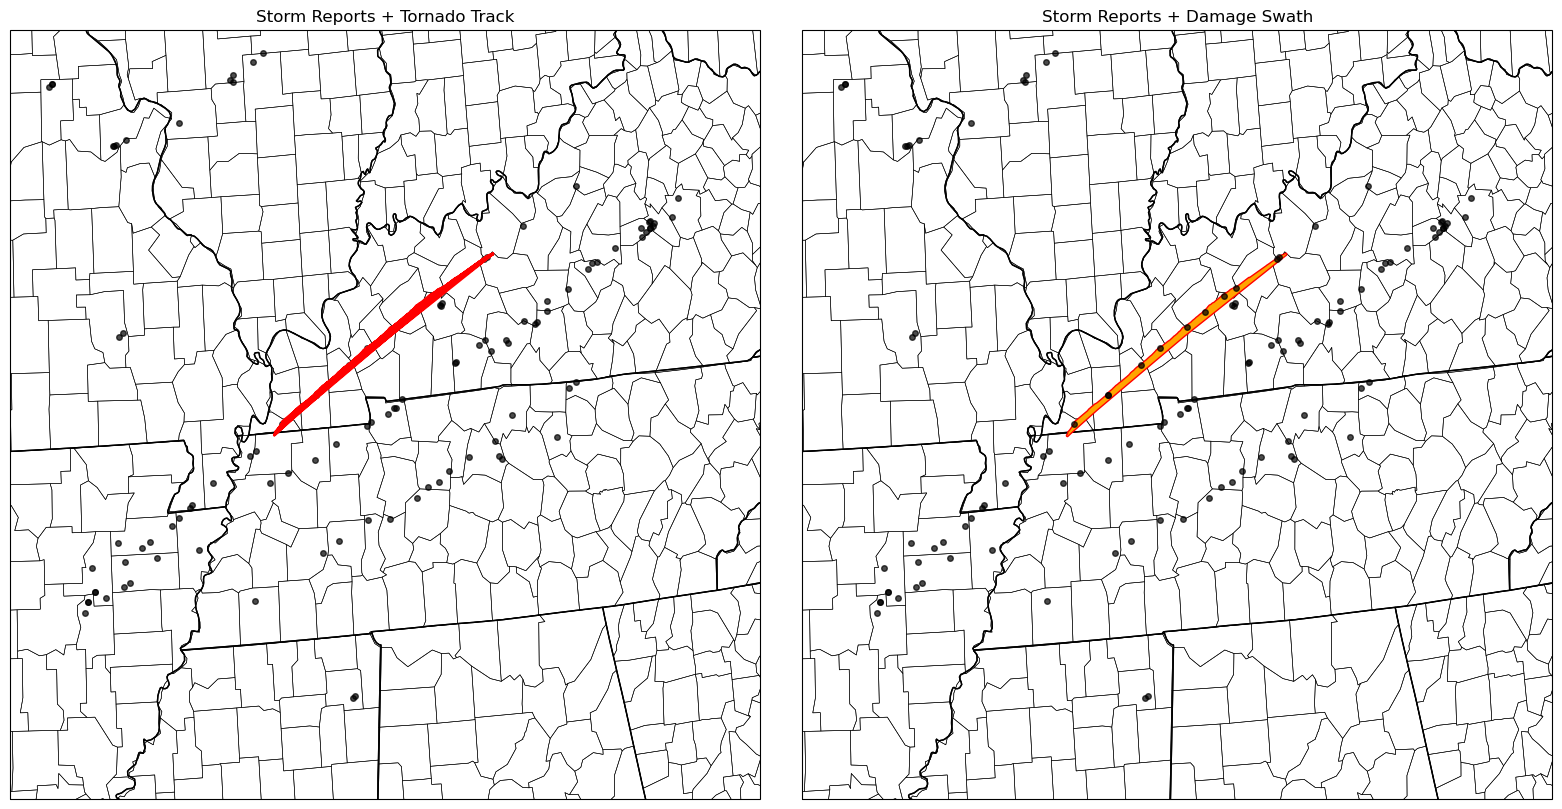

In [7]:
# Import proper libraries to plot storm reports, track, and damage swath

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from metpy.plots import USCOUNTIES

# Using AlbersEqualArea projection

proj = ccrs.AlbersEqualArea(
    central_longitude=-96,
    central_latitude=37.5,
    standard_parallels=(29.5,45.5)
)

# Create 2-panel plot

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 8),
    subplot_kw={"projection": proj}
)

swaths_ll = swaths.to_crs("EPSG:4326") # Convert to proper coordinate system
tracks_ll = tracks.to_crs("EPSG:4326") # Convert to proper coordinate system

# Add in all features needed for the plot
for ax in axes:
    ax._autoscaleXon = False
    ax._autoscaleYon = False
    ax.set_extent([-92, -84, 34, 39], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.STATES)
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(USCOUNTIES.with_scale('20m'), linewidth=0.4)

# Panel 1: reports + track
ax1 = axes[0]
ax1.scatter(
    reports_gdf["Lon"],
    reports_gdf["Lat"],
    transform=ccrs.PlateCarree(),
    s=16,
    color="black",
    alpha=0.7,
    zorder=3
)
tracks_ll.plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    color="red",
    linewidth=2,
    zorder=4
)
ax1.set_title("Storm Reports + Tornado Track")

# Panel 2: reports + swath
ax2 = axes[1]
ax2.scatter(
    reports_gdf["Lon"],
    reports_gdf["Lat"],
    transform=ccrs.PlateCarree(),
    s=16,
    color="black",
    alpha=0.7,
    zorder=3
)
swaths_ll.plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    facecolor="orange",
    edgecolor="red",
    alpha=1.0,
    linewidth=1.0,
    zorder=2
)
ax2.set_title("Storm Reports + Damage Swath")

plt.tight_layout()
plt.savefig('Track&DamageSwath.png')
plt.show()

In [8]:
# Download street network and building footprint data from OpenStreetMap
# for the Mayfield, KY area using OSMnx

place = "Mayfield, Kentucky, USA"

G = ox.graph_from_place(
    place,
    network_type="drive"
)

In [9]:
nodes, edges = ox.graph_to_gdfs(G) # nodes = intersections, edges = road segments

In [10]:
# Pull building data from OSM
tags = {"building": True}

buildings = ox.geometries_from_place(
    place,
    tags
)

buildings = gpd.GeoDataFrame(buildings, geometry="geometry", crs="EPSG:4326")

buildings = buildings[
    buildings.geometry.type.isin(["Polygon","MultiPolygon"]) # Identify specific geometry to filter all buildings
].copy()

In [11]:
# Clip all spatial datasets to a Mayfield bounding box
# to focus the analysis on the area most impacted by the tornado

from shapely.geometry import box

# approximate Mayfield zoom box in lon/lat -> convert to 3857 first if you want precise bounds
north = 36.82
south = 36.66
east = -88.56
west = -88.72
mayfield_bbox = ox.geometries_from_bbox(north, south, east, west, tags={"building": True})

# Convert bbox to Web Mercator
mayfield_bbox = mayfield_bbox.to_crs("EPSG:4326")

In [12]:
# Perform a spatial intersection between building footprints and the
# tornado swath polygon to identify potentially impacted structures

impacted_buildings = gpd.overlay(
    buildings,
    swaths_ll,
    how="intersection"
)

In [13]:
# Reproject spatial layers to Web Mercator (EPSG:3857)
# for compatibility with web-based basemaps

edges_mayfield = edges.to_crs("EPSG:3857")
nodes_mayfield = nodes.to_crs("EPSG:3857")
buildings_mayfield = buildings.to_crs("EPSG:3857")
impacted_buildings_mayfield = impacted_buildings.to_crs("EPSG:3857")
swath_mayfield = swaths_ll.to_crs("EPSG:3857")
mayfield_bbox = mayfield_bbox.to_crs("EPSG:3857")

In [14]:
import contextily as cx

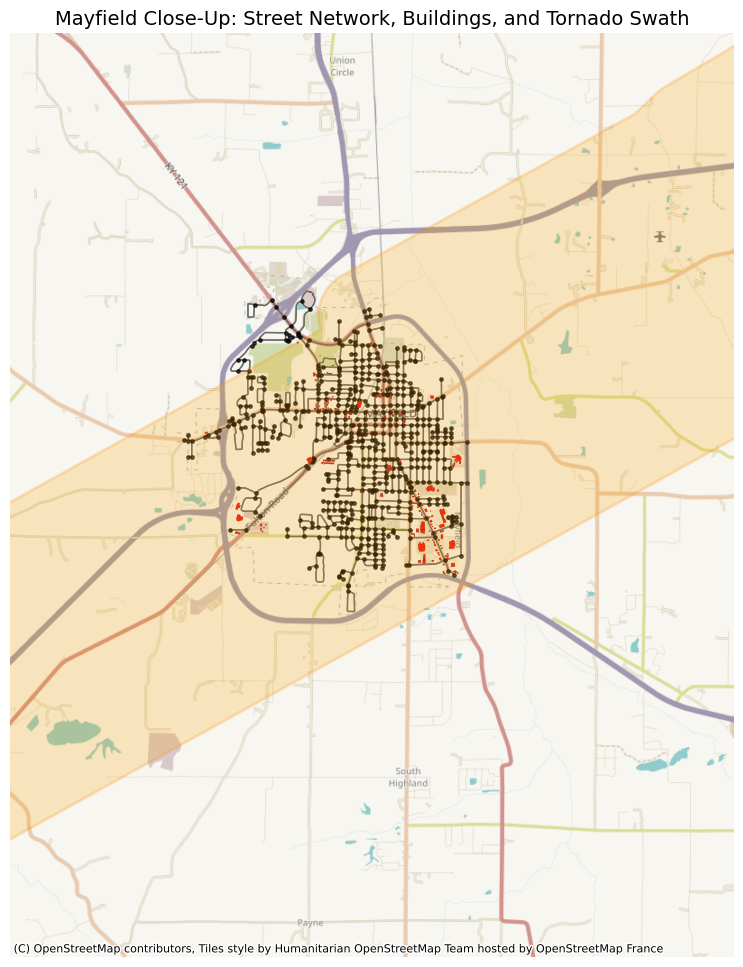

In [15]:
# Create a static GIS visualization showing the Mayfield street network,
# building footprints, and the tornado damage swath

fig, ax = plt.subplots(figsize=(12, 12))

# Roads
edges_mayfield.plot(
    ax=ax,
    linewidth=1.0,
    color="dimgray",
    alpha=0.9,
    zorder=2
)

# Nodes/intersections
nodes_mayfield.plot(
    ax=ax,
    color="black",
    markersize=6,
    alpha=0.7,
    zorder=3
)

# All buildings
buildings_mayfield.plot(
    ax=ax,
    color="lightgray",
    edgecolor="none",
    alpha=0.75,
    zorder=3
)

# Impacted buildings
impacted_buildings_mayfield.plot(
    ax=ax,
    color="red",
    edgecolor="darkred",
    linewidth=0.25,
    alpha=0.95,
    zorder=4
)

# Swath
swath_mayfield.plot(
    ax=ax,
    facecolor="orange",
    edgecolor="darkorange",
    alpha=0.22,
    linewidth=2.0,
    zorder=5
)

# Set extent to the Mayfield box, not the whole swath
xmin, ymin, xmax, ymax = mayfield_bbox.total_bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

cx.add_basemap(ax, crs="EPSG:3857")

ax.set_axis_off()
ax.set_title("Mayfield Close-Up: Street Network, Buildings, and Tornado Swath", fontsize=14)

plt.savefig('MayfieldNetwork&DamageSwath.png')
plt.show()

In [16]:
# Create an interactive Folium map centered on downtown Mayfield
# with the tornado track overlay and a marker showing courthouse damage

import folium
from folium import IFrame

# Approximate downtown Mayfield center
mayfield_center = [36.7415, -88.6450]

# Approximate location of the Graves County Courthouse
courthouse_lat = 36.7417
courthouse_lon = -88.6453

# Image URL
img_url = "https://www.weather.gov/images/pah/StormEvents/2021/Dec%2010-11%20Tornadoes/Update/Refresh%20Graves%205.jpg"

# Create map
m = folium.Map(
    location=mayfield_center,
    zoom_start=14,
    tiles="OpenStreetMap"
)

In [17]:

# Build popup HTML
html = f"""<h4>Graves County Courthouse</h4><p>Mayfield, Kentucky</p><img src="{img_url}" width="300">"""

iframe = IFrame(html=html, width=320, height=360)
popup = folium.Popup(iframe, max_width=350)
tooltip = folium.Tooltip(html)

# Add courthouse marker
folium.Marker(
    location=[courthouse_lat, courthouse_lon],
    popup=popup,
    tooltip=tooltip,
    icon=folium.Icon(color="red", icon="info-sign")
).add_to(m)

# Display map
m

In [18]:
m.save("mayfield_courthouse_damage_map.html")